# 04 — Machine Learning Model
Trains the flood-risk Random Forest, evaluates it, and runs SHAP analysis — the project's
core research contribution. Trains on `feature_matrix.csv`, which is now canonically the
39-year (1987-2025) rainfall climatology, so this **is** the 40-year retrain — `rf_baseline`
below is the primary/current model (saved at the end as `rf_model_40yr.joblib`). A dedicated
comparison section at the end reproduces the original 3-year-rainfall model fresh from a
frozen snapshot (`feature_matrix_3yr.csv`) to show what changed.

Pipeline: 01 Data Collection → 02 EDA → 03 Feature Engineering → **04 ML Model**

## Imports

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             f1_score, accuracy_score)
import shap

print("Libraries loaded!")

Libraries loaded!


## Load feature matrix
Now canonically the 39-year rainfall climatology (see 03_Feature_Engineering.ipynb).

In [2]:
BASE        = "/Users/riteshghorpade/Documents/010_Project/002_Dataset"
FEATURE_CSV = f"{BASE}/feature_matrix.csv"
FEATURE_CSV_3YR = f"{BASE}/feature_matrix_3yr.csv"   # frozen pre-rework snapshot, for comparison
MODEL_PATH  = f"{BASE}/rf_model_40yr.joblib"
MAPS_PATH   = f"{BASE}/004_Maps"

df = pd.read_csv(FEATURE_CSV)

print("Feature matrix loaded!")
print(f"\nShape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(df.head())

Feature matrix loaded!

Shape: (7843, 10)

Columns: ['elevation', 'dist_to_water', 'dist_to_clyde', 'building_count', 'road_count', 'mean_annual_mm_day', 'mean_winter_mm_day', 'wet_days_per_year', 'max_daily_mm', 'flood_risk']

First 5 rows:
   elevation  dist_to_water  dist_to_clyde  building_count  road_count  \
0          8     429.130538     429.130538              62          57   
1         17     808.615363    1228.448457              42          58   
2         14     724.363088    1135.327775              38          73   
3         13     644.627770    1043.142726              37          72   
4         12     571.303806     949.065747              44          71   

   mean_annual_mm_day  mean_winter_mm_day  wet_days_per_year  max_daily_mm  \
0            3.022107            3.723017         172.717949     32.273127   
1            2.944663            3.715277         166.717949     33.308127   
2            2.944663            3.715277         166.717949     33.308127   
3

## Prepare features (X) and label (y)

In [3]:
# ── Prepare features and labels ─────────────────────────────
# X = features (input to model)
# y = flood_risk label (what model predicts)

feature_cols = ['elevation', 'dist_to_water', 'dist_to_clyde',
                'building_count', 'road_count', 'mean_annual_mm_day',
                'mean_winter_mm_day', 'wet_days_per_year', 'max_daily_mm']

X = df[feature_cols]
y = df['flood_risk']

print("Features (X):")
print(f"  Shape: {X.shape}")
print(f"  Columns: {X.columns.tolist()}")

print(f"\nLabel (y):")
print(f"  Shape: {y.shape}")
print(f"  Classes: {sorted(y.unique())}")
print(f"  Distribution:")
for cls in [0, 1, 2]:
    name  = {0:'Low', 1:'Medium', 2:'High'}[cls]
    count = (y==cls).sum()
    pct   = count/len(y)*100
    print(f"    Class {cls} ({name}): {count:,} ({pct:.1f}%)")

Features (X):
  Shape: (7843, 9)
  Columns: ['elevation', 'dist_to_water', 'dist_to_clyde', 'building_count', 'road_count', 'mean_annual_mm_day', 'mean_winter_mm_day', 'wet_days_per_year', 'max_daily_mm']

Label (y):
  Shape: (7843,)
  Classes: [np.int64(0), np.int64(1), np.int64(2)]
  Distribution:
    Class 0 (Low): 3,790 (48.3%)
    Class 1 (Medium): 2,698 (34.4%)
    Class 2 (High): 1,355 (17.3%)


## Train/test split (80/20, stratified)

In [4]:
# ── Train/test split ────────────────────────────────────────
# 80% training, 20% testing
# Stratified to maintain class distribution in both sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # ensures same class % in train and test
)

print("Train/test split complete!")
print(f"\nTraining set: {X_train.shape[0]:,} points (80%)")
print(f"Testing set:  {X_test.shape[0]:,} points (20%)")

print(f"\nTraining class distribution:")
for cls in [0, 1, 2]:
    name  = {0:'Low', 1:'Medium', 2:'High'}[cls]
    count = (y_train==cls).sum()
    pct   = count/len(y_train)*100
    print(f"  Class {cls} ({name}): {count:,} ({pct:.1f}%)")

print(f"\nTesting class distribution:")
for cls in [0, 1, 2]:
    name  = {0:'Low', 1:'Medium', 2:'High'}[cls]
    count = (y_test==cls).sum()
    pct   = count/len(y_test)*100
    print(f"  Class {cls} ({name}): {count:,} ({pct:.1f}%)")

Train/test split complete!

Training set: 6,274 points (80%)
Testing set:  1,569 points (20%)

Training class distribution:
  Class 0 (Low): 3,032 (48.3%)
  Class 1 (Medium): 2,158 (34.4%)
  Class 2 (High): 1,084 (17.3%)

Testing class distribution:
  Class 0 (Low): 758 (48.3%)
  Class 1 (Medium): 540 (34.4%)
  Class 2 (High): 271 (17.3%)


## Train the Random Forest — primary/current model

In [5]:
# ── Train baseline Random Forest ────────────────────────────
# Default settings first to establish baseline performance
# Then we will tune hyperparameters

print("Training baseline Random Forest...")

rf_baseline = RandomForestClassifier(
    n_estimators=100,  # 100 decision trees
    random_state=42,   # reproducible results
    n_jobs=-1          # use all CPU cores
)

rf_baseline.fit(X_train, y_train)

print("Training complete!")

# Evaluate on test set
y_pred = rf_baseline.predict(X_test)

print(f"\nBaseline Model Performance:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"  F1 Score (macro): {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"  F1 Score (weighted): {f1_score(y_test, y_pred, average='weighted'):.4f}")

Training baseline Random Forest...
Training complete!

Baseline Model Performance:
  Accuracy: 0.9962
  F1 Score (macro): 0.9950
  F1 Score (weighted): 0.9962


## Classification report

In [6]:
# ── Classification report ───────────────────────────────────
print("Detailed Classification Report:")
print("=" * 55)
print(classification_report(
    y_test, y_pred,
    target_names=['Low risk', 'Medium risk', 'High risk']
))

Detailed Classification Report:
              precision    recall  f1-score   support

    Low risk       1.00      1.00      1.00       758
 Medium risk       1.00      1.00      1.00       540
   High risk       0.99      0.99      0.99       271

    accuracy                           1.00      1569
   macro avg       0.99      0.99      0.99      1569
weighted avg       1.00      1.00      1.00      1569



## Confusion matrix

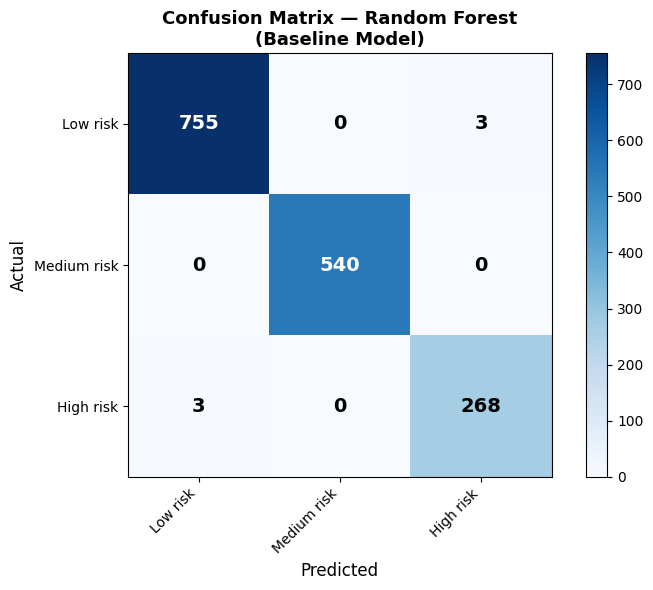

Saved!


In [7]:
# ── Confusion matrix ────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im)

classes = ['Low risk', 'Medium risk', 'High risk']
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(classes, rotation=45, ha='right')
ax.set_yticklabels(classes)

for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i,j], ha='center', va='center',
                fontsize=14, fontweight='bold',
                color='white' if cm[i,j] > cm.max()/2 else 'black')

ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("Actual", fontsize=12)
ax.set_title("Confusion Matrix — Random Forest\n(Baseline Model)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{MAPS_PATH}/confusion_matrix.png", dpi=150)
plt.show()
print("Saved!")

## Deeper model evaluation — cross-validation and baselines
The single 80/20 test-set result above (99.62% accuracy) could in principle be a
lucky split. This section adds three things to stress-test that number:

1. **Standard random-split 5-fold cross-validation** — confirms the single split
   isn't an outlier.
2. **Spatial-block cross-validation** — the 100m grid points are spatially
   autocorrelated (a point's neighbours 100-200m away have near-identical
   elevation, distance and rainfall values), so a *random* split can put
   near-duplicate points in both train and test, inflating the random-CV
   number. Spatial-block CV instead groups points into 500m tiles and assigns
   each tile wholesale to either train or test, so no fold can "cheat" using a
   near-neighbour of a test point.
3. **Two baselines** — a majority-class baseline (floor) and a baseline that
   directly applies the same elevation/SEPA-PVA-zone rule the label was built
   from (ceiling), so the Random Forest's numbers have something concrete to
   sit between.

### Random-split 5-fold cross-validation

In [8]:
# ── Random-split 5-fold CV (standard StratifiedKFold) ───────
from sklearn.model_selection import StratifiedKFold, cross_validate

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_for_cv = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

random_cv = cross_validate(
    rf_for_cv, X, y, cv=skf,
    scoring={'accuracy': 'accuracy', 'f1_macro': 'f1_macro'},
    n_jobs=-1,
)

random_cv_acc_mean = random_cv['test_accuracy'].mean()
random_cv_acc_std  = random_cv['test_accuracy'].std()
random_cv_f1_mean  = random_cv['test_f1_macro'].mean()
random_cv_f1_std   = random_cv['test_f1_macro'].std()

print("Random-split 5-fold CV — per-fold accuracy:", np.round(random_cv['test_accuracy'], 4))
print("Random-split 5-fold CV — per-fold F1 macro: ", np.round(random_cv['test_f1_macro'], 4))
print(f"\nMean accuracy: {random_cv_acc_mean:.4f} ± {random_cv_acc_std:.4f}")
print(f"Mean F1 macro: {random_cv_f1_mean:.4f} ± {random_cv_f1_std:.4f}")

Random-split 5-fold CV — per-fold accuracy: [0.9917 0.9943 0.9904 0.9949 0.9917]
Random-split 5-fold CV — per-fold F1 macro:  [0.9891 0.9925 0.9876 0.9933 0.9892]

Mean accuracy: 0.9926 ± 0.0017
Mean F1 macro: 0.9904 ± 0.0022


### Spatial-block cross-validation
Loads `feature_matrix_with_coords.csv` (same rows, same order, plus
`easting`/`northing`) purely to build the spatial blocks — the model itself
still trains only on the 9 declared feature columns, coordinates are never a
model input.

In [9]:
# ── Build 500m spatial blocks from grid coordinates ──────────
FEATURE_CSV_COORDS = f"{BASE}/feature_matrix_with_coords.csv"
df_coords = pd.read_csv(FEATURE_CSV_COORDS)

assert len(df_coords) == len(df), "row count mismatch between feature_matrix.csv and feature_matrix_with_coords.csv"
assert np.allclose(df_coords['elevation'].values, df['elevation'].values), "row order mismatch between the two feature matrix files"

BLOCK_SIZE_M = 500  # coarser than the 100m point spacing; fine enough to keep 5 folds reasonably balanced

block_x = (df_coords['easting']  // BLOCK_SIZE_M).astype(int)
block_y = (df_coords['northing'] // BLOCK_SIZE_M).astype(int)
block_id = (block_x.astype(str) + "_" + block_y.astype(str)).values

block_sizes = pd.Series(block_id).value_counts()
block_id_n = pd.Series(block_id).nunique()
print(f"Spatial blocks ({BLOCK_SIZE_M}m tiles): {block_id_n}")
print(f"Points per block — mean: {block_sizes.mean():.1f}, min: {block_sizes.min()}, max: {block_sizes.max()}")

Spatial blocks (500m tiles): 340
Points per block — mean: 23.1, min: 1, max: 25


In [10]:
# ── Spatial-block 5-fold CV (GroupKFold — whole blocks go to train OR test) ──
from sklearn.model_selection import GroupKFold

gkf = GroupKFold(n_splits=5)
spatial_acc_scores, spatial_f1_scores = [], []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=block_id)):
    rf_fold = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_fold.fit(X.iloc[train_idx], y.iloc[train_idx])
    fold_pred = rf_fold.predict(X.iloc[test_idx])

    fold_acc = accuracy_score(y.iloc[test_idx], fold_pred)
    fold_f1  = f1_score(y.iloc[test_idx], fold_pred, average='macro')
    spatial_acc_scores.append(fold_acc)
    spatial_f1_scores.append(fold_f1)

    n_train_blocks = pd.Series(block_id[train_idx]).nunique()
    n_test_blocks  = pd.Series(block_id[test_idx]).nunique()
    print(f"  Fold {fold+1}: {len(train_idx):,} train pts ({n_train_blocks} blocks) / "
          f"{len(test_idx):,} test pts ({n_test_blocks} blocks) — "
          f"accuracy {fold_acc:.4f}, F1 macro {fold_f1:.4f}")

spatial_cv_acc_mean = np.mean(spatial_acc_scores)
spatial_cv_acc_std  = np.std(spatial_acc_scores)
spatial_cv_f1_mean  = np.mean(spatial_f1_scores)
spatial_cv_f1_std   = np.std(spatial_f1_scores)

print(f"\nMean accuracy: {spatial_cv_acc_mean:.4f} ± {spatial_cv_acc_std:.4f}")
print(f"Mean F1 macro: {spatial_cv_f1_mean:.4f} ± {spatial_cv_f1_std:.4f}")

  Fold 1: 6,274 train pts (271 blocks) / 1,569 test pts (69 blocks) — accuracy 0.9968, F1 macro 0.9957


  Fold 2: 6,275 train pts (272 blocks) / 1,568 test pts (68 blocks) — accuracy 0.9943, F1 macro 0.9927
  Fold 3: 6,274 train pts (273 blocks) / 1,569 test pts (67 blocks) — accuracy 0.9885, F1 macro 0.9847


  Fold 4: 6,274 train pts (273 blocks) / 1,569 test pts (67 blocks) — accuracy 0.9873, F1 macro 0.9837


  Fold 5: 6,275 train pts (271 blocks) / 1,568 test pts (69 blocks) — accuracy 0.9936, F1 macro 0.9918

Mean accuracy: 0.9921 ± 0.0036
Mean F1 macro: 0.9897 ± 0.0047


In [11]:
# ── Random-split vs spatial-block CV — side by side ─────────
cv_comparison = pd.DataFrame({
    'Accuracy (mean ± std)': [
        f"{random_cv_acc_mean:.4f} ± {random_cv_acc_std:.4f}",
        f"{spatial_cv_acc_mean:.4f} ± {spatial_cv_acc_std:.4f}",
    ],
    'F1 macro (mean ± std)': [
        f"{random_cv_f1_mean:.4f} ± {random_cv_f1_std:.4f}",
        f"{spatial_cv_f1_mean:.4f} ± {spatial_cv_f1_std:.4f}",
    ],
}, index=['Random-split 5-fold CV', 'Spatial-block 5-fold CV'])

print(cv_comparison)
print(f"\nAccuracy gap (random − spatial): {random_cv_acc_mean - spatial_cv_acc_mean:.4f}")
print(f"F1 macro gap (random − spatial):  {random_cv_f1_mean - spatial_cv_f1_mean:.4f}")

                        Accuracy (mean ± std) F1 macro (mean ± std)
Random-split 5-fold CV        0.9926 ± 0.0017       0.9904 ± 0.0022
Spatial-block 5-fold CV       0.9921 ± 0.0036       0.9897 ± 0.0047

Accuracy gap (random − spatial): 0.0005
F1 macro gap (random − spatial):  0.0006


### Interpreting the spatial-CV comparison

Contrary to the concern that motivated this test, spatial-block CV (**99.21% ± 0.36%**
accuracy) is barely different from random-split CV (**99.26% ± 0.17%** accuracy) — a gap
of 0.05 percentage points, well within the overlap of the two spreads. Spatial
autocorrelation between neighbouring 100m grid points does not appear to meaningfully
inflate the random-split number in this dataset.

The more informative difference is in the *spread*, not the mean: spatial-block folds
range from 98.73% to 99.68% (std 0.36%), roughly double the random-split folds' spread
(99.04%–99.49%, std 0.17%). This is the expected signature of spatial autocorrelation
showing up as fold-to-fold variance rather than a shifted mean — Folds 3 and 4 (both
~98.7–98.9%) land on 500m blocks that are harder for the model to generalise to, while
other folds sit closer to the random-split performance.

A plausible reason the *mean* barely moves: elevation and the distance-to-water features
vary over kilometre-scale gradients across the 5km study circle, and the underlying
labelling rule is a simple, near-linear function of two of those inputs. A Random Forest
with well-populated internal splits generalises across nearby 500m blocks about as well as
across randomly-scattered points, because the rule it's approximating doesn't have
fine-grained local exceptions for it to overfit to in the first place.

**Honest conclusion**: spatial-block CV does not overturn the random-split CV headline
number here, but it remains the more conservative and defensible figure to report, since
it doesn't rely on the (here, apparently mild) assumption that nearby points are
exchangeable between train and test. Both are reported in the summary table below rather
than picking one.

## Baseline comparisons

In [12]:
# ── Baseline 1: majority-class (always predicts the most common class) ──
from sklearn.dummy import DummyClassifier

majority_clf = DummyClassifier(strategy='most_frequent', random_state=42)
majority_clf.fit(X_train, y_train)
majority_pred = majority_clf.predict(X_test)

majority_acc = accuracy_score(y_test, majority_pred)
majority_f1  = f1_score(y_test, majority_pred, average='macro')

print(f"Majority-class baseline (always predicts class {majority_pred[0]} — Low risk):")
print(f"  Accuracy: {majority_acc:.4f}")
print(f"  F1 macro: {majority_f1:.4f}")

Majority-class baseline (always predicts class 0 — Low risk):
  Accuracy: 0.4831
  F1 macro: 0.2172


In [13]:
# ── Baseline 2: rule-based (directly reapplies the elevation + SEPA PVA rule) ──
# Reconstructs PVA-zone membership fresh via the identical spatial join used to
# build the label in 03_Feature_Engineering.ipynb (Step 8), then applies the
# same threshold rule. This is not a trained model — it's the labelling rule
# itself, run as a classifier, so it shows the ceiling the Random Forest is
# approaching rather than a competing model.
import geopandas as gpd
from shapely.geometry import Point

SEPA_PATH = f"{BASE}/001_SEPA/GeoPackage/Data/PVAv2.gpkg"
RULE_UNI_X, RULE_UNI_Y, RULE_RADIUS = 260983, 665006, 5000

pva = gpd.read_file(SEPA_PATH)
pva_glasgow = pva[pva.geometry.intersects(Point(RULE_UNI_X, RULE_UNI_Y).buffer(RULE_RADIUS))].copy()

points_gdf = gpd.GeoDataFrame(
    df_coords.reset_index().rename(columns={'index': 'row_id'}),
    geometry=gpd.points_from_xy(df_coords['easting'], df_coords['northing']),
    crs="EPSG:27700",
)
joined = gpd.sjoin(points_gdf, pva_glasgow[['PVA_Name', 'geometry']], how='left', predicate='within')
joined = joined.drop_duplicates(subset='row_id').sort_values('row_id').reset_index(drop=True)
inside_pva = joined['PVA_Name'].notna().astype(int).values

def rule_based_predict(elevation, inside_pva):
    pred = np.zeros(len(elevation), dtype=int)
    pred[(inside_pva == 1) & (elevation <= 35)] = 1
    pred[(inside_pva == 1) & (elevation <= 15)] = 2
    return pred

rule_pred_all = rule_based_predict(df_coords['elevation'].values, inside_pva)

rule_acc_full = accuracy_score(y, rule_pred_all)
rule_f1_full  = f1_score(y, rule_pred_all, average='macro')
n_mismatch    = int((rule_pred_all != y.values).sum())

# Same held-out test rows as every other number in this notebook, for a like-for-like table
rule_pred_test = rule_pred_all[X_test.index.values]
rule_acc_test  = accuracy_score(y_test, rule_pred_test)
rule_f1_test   = f1_score(y_test, rule_pred_test, average='macro')

print("Rule-based baseline (elevation + SEPA PVA zone thresholds — the exact label rule):")
print(f"  Full dataset (all {len(y):,} points) — accuracy: {rule_acc_full:.4f}, F1 macro: {rule_f1_full:.4f}")
print(f"    Mismatches vs. the stored label: {n_mismatch} of {len(y):,}")
print(f"  Held-out test set only            — accuracy: {rule_acc_test:.4f}, F1 macro: {rule_f1_test:.4f}")

Rule-based baseline (elevation + SEPA PVA zone thresholds — the exact label rule):
  Full dataset (all 7,843 points) — accuracy: 1.0000, F1 macro: 1.0000
    Mismatches vs. the stored label: 0 of 7,843
  Held-out test set only            — accuracy: 1.0000, F1 macro: 1.0000


## Summary — baselines and cross-validation, side by side

| Approach | Accuracy | F1 macro | What it represents |
|---|---|---|---|
| Majority-class baseline | 48.31% | 21.72% | Floor — always predicts Low risk (48.3% of points) |
| Random Forest — single 80/20 split | 99.62% | 99.50% | Existing headline number (Section 3.4) |
| Random Forest — random-split 5-fold CV | 99.26% ± 0.17% | 99.04% ± 0.22% | Confirms the single split wasn't a lucky draw |
| Random Forest — spatial-block 5-fold CV | 99.21% ± 0.36% | 98.97% ± 0.47% | More conservative estimate, accounting for spatial autocorrelation |
| Rule-based baseline (elevation + PVA) | 100.00% | 100.00% | Ceiling — the label's own generation rule, reapplied directly |

### What this comparison actually demonstrates

Read top to bottom, this table tells a specific, bounded story:

- **The majority-class floor (48.3% accuracy) is a long way below the Random Forest's
  ~99%** — so the model is clearly learning *something* beyond the class imbalance.
- **The rule-based ceiling sits at exactly 100%** (0 mismatches across all 7,843 points),
  because `flood_risk` is deterministically generated from elevation and SEPA PVA-zone
  membership (Section 3.2.2), and this baseline reapplies that exact rule rather than
  approximating it. This is the crucial piece of context for the Random Forest's headline
  accuracy: it isn't approaching some unknown, hard-to-model real-world quantity — it's
  approaching a **known, fully-specified rule that a simple threshold check reproduces
  perfectly**. The Random Forest's 99.2–99.6% (across all three evaluation methods) is
  therefore best read as *"how close can a general-purpose classifier, given only
  continuous proxies for the rule's two inputs, get to reconstructing that rule"* — not as
  evidence the model would predict real, observed flooding at 99% accuracy.
- **Random-split and spatial-block CV agree closely** (99.26% vs 99.21%), so — in this
  specific dataset — spatial autocorrelation is not the dominant source of the ~0.7–0.8
  percentage point gap between the Random Forest and the rule-based ceiling. That gap
  instead reflects the genuine difficulty of recovering exact elevation thresholds (≤15m,
  ≤35m) and PVA membership from continuous, indirect proxy features (`dist_to_water`,
  `dist_to_clyde`, etc.) rather than from elevation and zone membership directly.

None of this invalidates the modelling exercise — the SHAP explanations later in this
notebook still depend on the Random Forest having correctly learned the elevation/PVA-
driven decision boundary well enough to explain it per point, which these figures confirm
it has. But consistent with the caveat already carried in the dashboard and dissertation
Section 3.8, these numbers should be read as **the model successfully reconstructing a
known labelling rule**, bounded below by a naive baseline and above by the rule itself —
not as validated performance against independently observed flood events.

## Feature importance

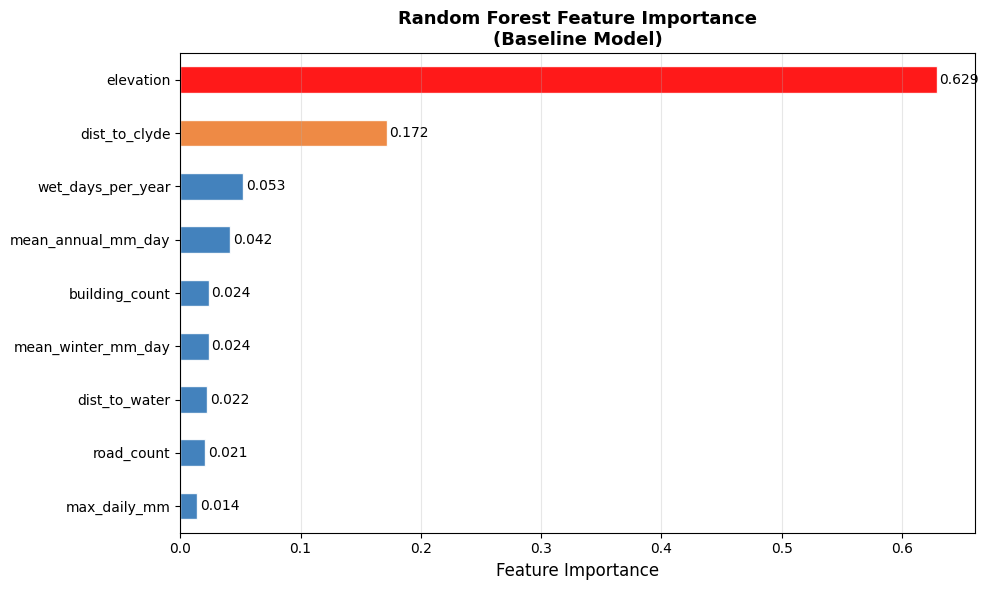

Feature importance:
  elevation              0.6292
  dist_to_clyde          0.1716
  wet_days_per_year      0.0526
  mean_annual_mm_day     0.0418
  building_count         0.0238
  mean_winter_mm_day     0.0236
  dist_to_water          0.0225
  road_count             0.0209
  max_daily_mm           0.0142


In [14]:
# ── Feature importance ──────────────────────────────────────
importances = rf_baseline.feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#FF0000' if v >= 0.3 else '#ED7D31' if v >= 0.1 else '#2E75B6'
          for v in feat_imp.values]
feat_imp.plot.barh(ax=ax, color=colors, edgecolor='white', alpha=0.9)

ax.set_xlabel("Feature Importance", fontsize=12)
ax.set_title("Random Forest Feature Importance\n(Baseline Model)",
             fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

for i, v in enumerate(feat_imp.values):
    ax.text(v + 0.002, i, f"{v:.3f}", va='center', fontsize=10)

plt.tight_layout()
plt.savefig(f"{MAPS_PATH}/feature_importance.png", dpi=150)
plt.show()

print("Feature importance:")
for feat, imp in feat_imp.sort_values(ascending=False).items():
    print(f"  {feat:<22} {imp:.4f}")

## SHAP analysis (raw output)

In [15]:
# ── SHAP Analysis ───────────────────────────────────────────
# SHAP explains WHY the model made each prediction
# This is the core of your unique research contribution

print("Running SHAP analysis...")
print("This may take 2-3 minutes...")

# Use a sample for speed
X_sample = X_test.sample(n=500, random_state=42)

# Create SHAP explainer
explainer = shap.TreeExplainer(rf_baseline)
shap_values = explainer.shap_values(X_sample)

print("SHAP analysis complete!")
print(f"SHAP values shape: {np.array(shap_values).shape}")

Running SHAP analysis...
This may take 2-3 minutes...


SHAP analysis complete!
SHAP values shape: (500, 9, 3)


## SHAP summary plots per risk class

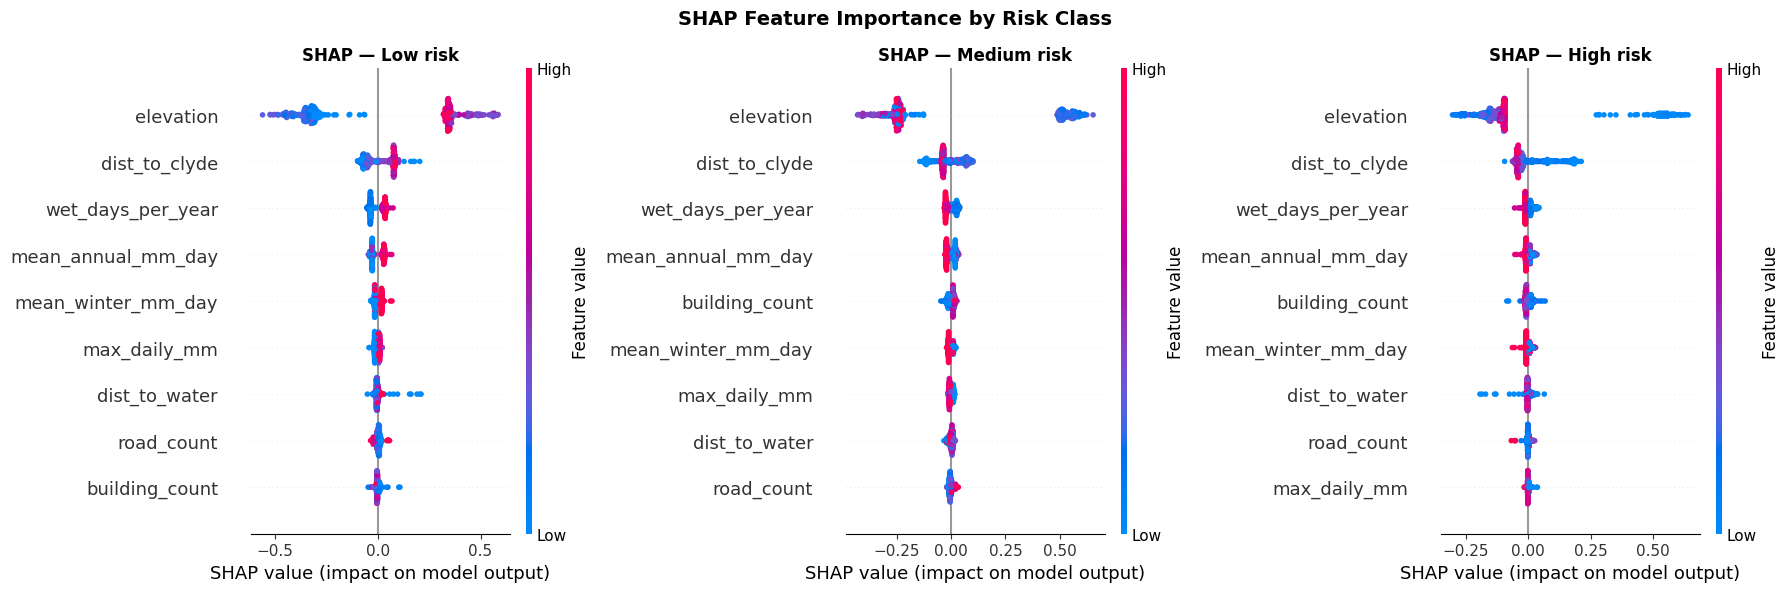

SHAP summary saved!


In [16]:
# ── SHAP Summary Plot ───────────────────────────────────────
# Shows which features matter most for each prediction
# and in which direction they push the prediction

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
class_names = ['Low risk', 'Medium risk', 'High risk']

for i, (ax, name) in enumerate(zip(axes, class_names)):
    plt.sca(ax)
    shap.summary_plot(
        shap_values[:, :, i],
        X_sample,
        feature_names=feature_cols,
        show=False,
        plot_size=None
    )
    ax.set_title(f"SHAP — {name}", fontsize=12, fontweight='bold')

plt.suptitle("SHAP Feature Importance by Risk Class",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{MAPS_PATH}/shap_summary.png", dpi=150, bbox_inches='tight')
plt.show()
print("SHAP summary saved!")

## Identify representative Low/High risk points for waterfall plots

In [17]:
import numpy as np

# Assuming you already have:
# - shap_values: SHAP values for your 500 test samples (list of arrays, one per class)
# - X_test_sample: the corresponding feature rows
# - y_pred: model predictions for those 500 samples

# Find a confident Low risk example (class 0)
low_risk_idx = np.where(y_pred == 0)[0][0]

# Find a confident High risk example (class 2)
high_risk_idx = np.where(y_pred == 2)[0][0]

print("Low risk example index:", low_risk_idx)
print("High risk example index:", high_risk_idx)

Low risk example index: 0
High risk example index: 1


## SHAP waterfall — Low & High risk (raw output, corrected indexing)

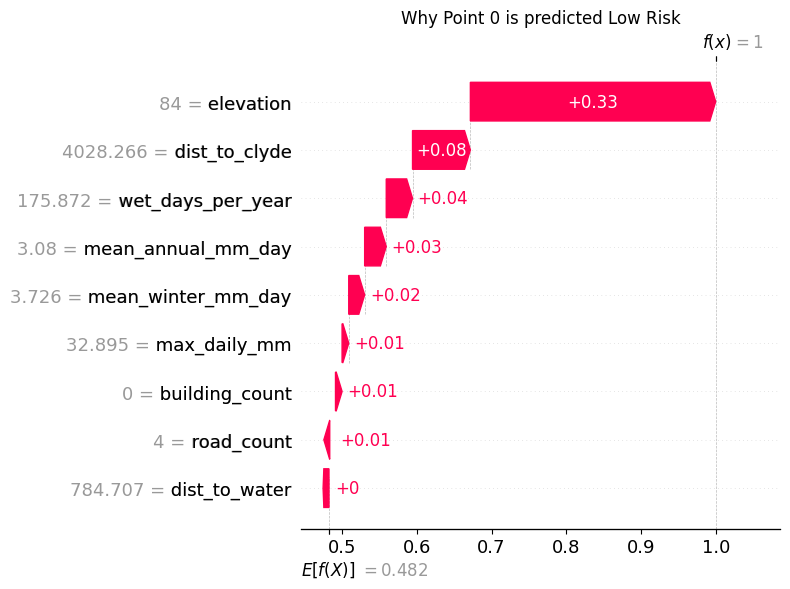

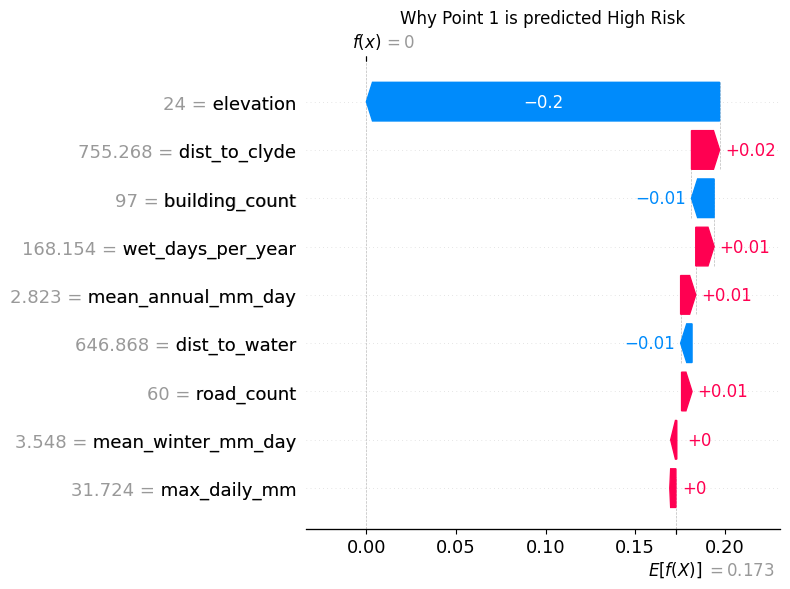

In [18]:
import shap
import matplotlib.pyplot as plt

# --- Low risk example ---
plt.figure()
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[low_risk_idx, :, 0],        # all 9 features, class 0 (Low), this point
        base_values=explainer.expected_value[0],
        data=X_sample.iloc[low_risk_idx],
        feature_names=X_sample.columns.tolist()
    ),
    show=False
)
plt.title(f"Why Point {low_risk_idx} is predicted Low Risk")
plt.tight_layout()
plt.savefig("shap_waterfall_low_risk.png", dpi=150)
plt.show()

# --- High risk example ---
plt.figure()
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[high_risk_idx, :, 2],       # all 9 features, class 2 (High), this point
        base_values=explainer.expected_value[2],
        data=X_sample.iloc[high_risk_idx],
        feature_names=X_sample.columns.tolist()
    ),
    show=False
)
plt.title(f"Why Point {high_risk_idx} is predicted High Risk")
plt.tight_layout()
plt.savefig("shap_waterfall_high_risk.png", dpi=150)
plt.show()

## Rebuild SHAP explainer in probability space

In [19]:
import shap

# Rebuild the explainer so SHAP values are in probability space
explainer_proba = shap.TreeExplainer(
    rf_baseline,
    data=X_train,                     # background dataset for probability calibration
    model_output="probability"
)

# Recompute SHAP values for your 500-sample set
shap_values_proba = explainer_proba.shap_values(X_sample)

print(np.array(shap_values_proba).shape)

(500, 9, 3)


## SHAP waterfall — Low & High risk (probability space)

Most confident Low risk index: 0 prob: 1.0
Most confident High risk index: 4 prob: 1.0


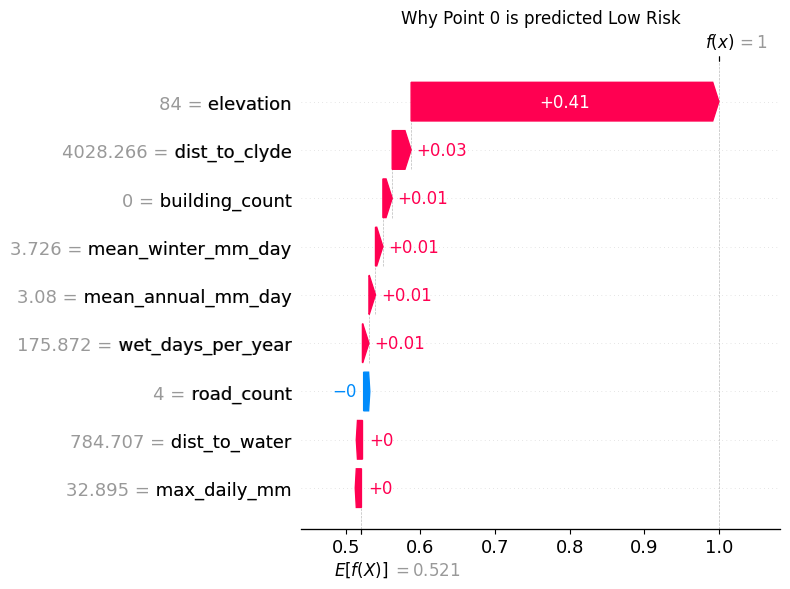

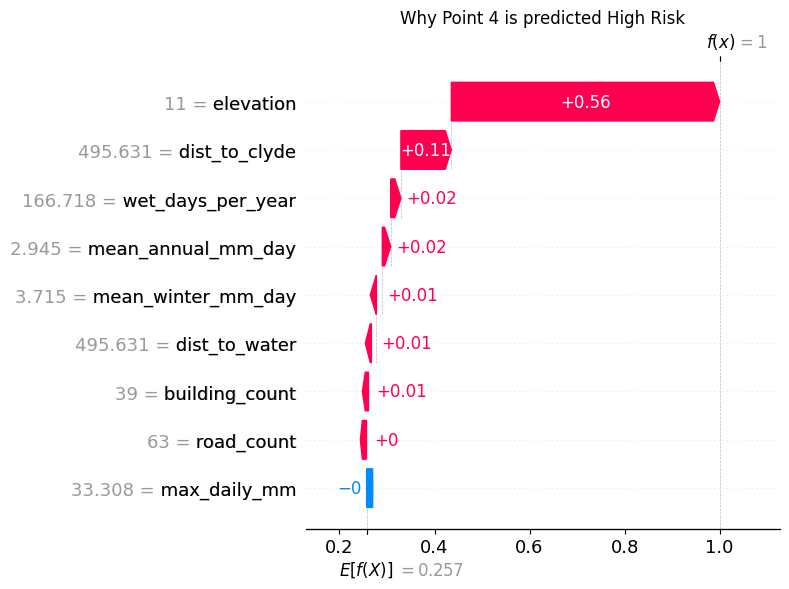

In [20]:
probs = rf_baseline.predict_proba(X_sample)

low_risk_idx = np.argmax(probs[:, 0])
high_risk_idx = np.argmax(probs[:, 2])

print("Most confident Low risk index:", low_risk_idx, "prob:", probs[low_risk_idx, 0])
print("Most confident High risk index:", high_risk_idx, "prob:", probs[high_risk_idx, 2])

# --- Low risk example ---
plt.figure()
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_proba[low_risk_idx, :, 0],
        base_values=explainer_proba.expected_value[0],
        data=X_sample.iloc[low_risk_idx],
        feature_names=X_sample.columns.tolist()
    ),
    show=False
)
plt.title(f"Why Point {low_risk_idx} is predicted Low Risk")
plt.tight_layout()
plt.savefig("shap_waterfall_low_risk_proba.png", dpi=150)
plt.show()

# --- High risk example ---
plt.figure()
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_proba[high_risk_idx, :, 2],
        base_values=explainer_proba.expected_value[2],
        data=X_sample.iloc[high_risk_idx],
        feature_names=X_sample.columns.tolist()
    ),
    show=False
)
plt.title(f"Why Point {high_risk_idx} is predicted High Risk")
plt.tight_layout()
plt.savefig("shap_waterfall_high_risk_proba.png", dpi=150)
plt.show()

## Sanity check — dist_to_clyde vs dist_to_water independence
Confirms the two distance features aren't accidentally duplicating each other.

In [21]:
import pandas as pd

# Check 1: how many points have dist_to_clyde exactly equal to dist_to_water?
exact_matches = (df['dist_to_clyde'] == df['dist_to_water']).sum()
print(f"Points where dist_to_clyde == dist_to_water exactly: {exact_matches} out of {len(df)}")

# Check 2: how correlated are the two columns overall?
corr = df['dist_to_clyde'].corr(df['dist_to_water'])
print(f"Correlation between dist_to_clyde and dist_to_water: {corr:.4f}")

# Check 3: look at a broader sample of rows where they're close or equal
close_matches = df[np.isclose(df['dist_to_clyde'], df['dist_to_water'], atol=0.01)]
print(f"Points where they're nearly identical (within 0.01m): {len(close_matches)}")
print(close_matches[['dist_to_clyde', 'dist_to_water']].head(10))

Points where dist_to_clyde == dist_to_water exactly: 1426 out of 7843
Correlation between dist_to_clyde and dist_to_water: 0.2515
Points where they're nearly identical (within 0.01m): 1426
    dist_to_clyde  dist_to_water
0      429.130538     429.130538
10     382.370562     382.370562
11     293.976532     293.976532
12     205.601895     205.601895
13     127.246622     127.246622
14      97.786094      97.786094
15      70.416797      70.416797
16       0.000000       0.000000
17       0.000000       0.000000
18      20.485543      20.485543


## SHAP waterfall — Medium risk (probability space)

Most confident Medium risk index: 1 prob: 1.0


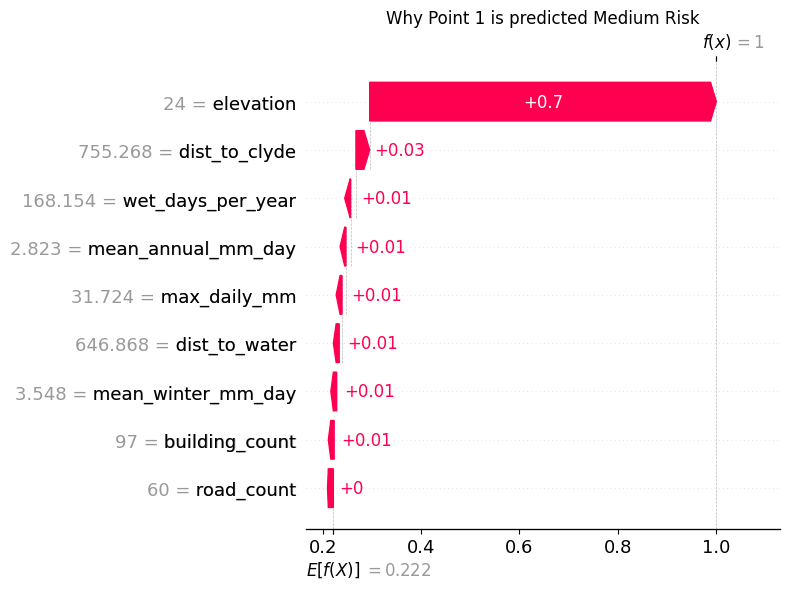

In [22]:
# Most confident Medium risk point (class 1)
medium_risk_idx = np.argmax(probs[:, 1])

print("Most confident Medium risk index:", medium_risk_idx, "prob:", probs[medium_risk_idx, 1])

plt.figure()
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_proba[medium_risk_idx, :, 1],
        base_values=explainer_proba.expected_value[1],
        data=X_sample.iloc[medium_risk_idx],
        feature_names=X_sample.columns.tolist()
    ),
    show=False
)
plt.title(f"Why Point {medium_risk_idx} is predicted Medium Risk")
plt.tight_layout()
plt.savefig("shap_waterfall_medium_risk_proba.png", dpi=150)
plt.show()

## Inspect the 3 representative points' feature values

In [23]:
print(X_sample.iloc[[low_risk_idx, high_risk_idx, medium_risk_idx]])

      elevation  dist_to_water  dist_to_clyde  building_count  road_count  \
7389         84     784.706612    4028.265628               0           4   
2341         11     495.631422     495.631422              39          63   
4805         24     646.868456     755.267906              97          60   

      mean_annual_mm_day  mean_winter_mm_day  wet_days_per_year  max_daily_mm  
7389            3.080200            3.725665         175.871795     32.895132  
2341            2.944663            3.715277         166.717949     33.308127  
4805            2.823062            3.547649         168.153846     31.724209  


## XGBoost — comparison model
Trains an `XGBClassifier` on the exact same `feature_cols`/`X_train`/`X_test`/`y_train`/`y_test`
split as `rf_baseline` above (same `random_state=42`), so the two models are directly
comparable. This is a comparison model only — `rf_baseline` remains the primary model used
for live dashboard predictions unless this comparison shows a meaningful improvement.

In [24]:
# ── Train XGBoost (comparison model) ────────────────────────
from xgboost import XGBClassifier

print("Training XGBoost...")

xgb_baseline = XGBClassifier(
    n_estimators=100,   # same tree count as the Random Forest, for a fair comparison
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss',
)

xgb_baseline.fit(X_train, y_train)

print("Training complete!")

xgb_pred = xgb_baseline.predict(X_test)

print(f"\nXGBoost Model Performance:")
print(f"  Accuracy: {accuracy_score(y_test, xgb_pred):.4f}")
print(f"  F1 Score (macro): {f1_score(y_test, xgb_pred, average='macro'):.4f}")
print(f"  F1 Score (weighted): {f1_score(y_test, xgb_pred, average='weighted'):.4f}")

Training XGBoost...


Training complete!

XGBoost Model Performance:
  Accuracy: 0.9936
  F1 Score (macro): 0.9917
  F1 Score (weighted): 0.9936


## XGBoost — classification report

In [25]:
print("Detailed Classification Report — XGBoost:")
print("=" * 55)
print(classification_report(
    y_test, xgb_pred,
    target_names=['Low risk', 'Medium risk', 'High risk']
))

Detailed Classification Report — XGBoost:
              precision    recall  f1-score   support

    Low risk       0.99      0.99      0.99       758
 Medium risk       1.00      1.00      1.00       540
   High risk       0.98      0.99      0.98       271

    accuracy                           0.99      1569
   macro avg       0.99      0.99      0.99      1569
weighted avg       0.99      0.99      0.99      1569



## XGBoost — feature importance

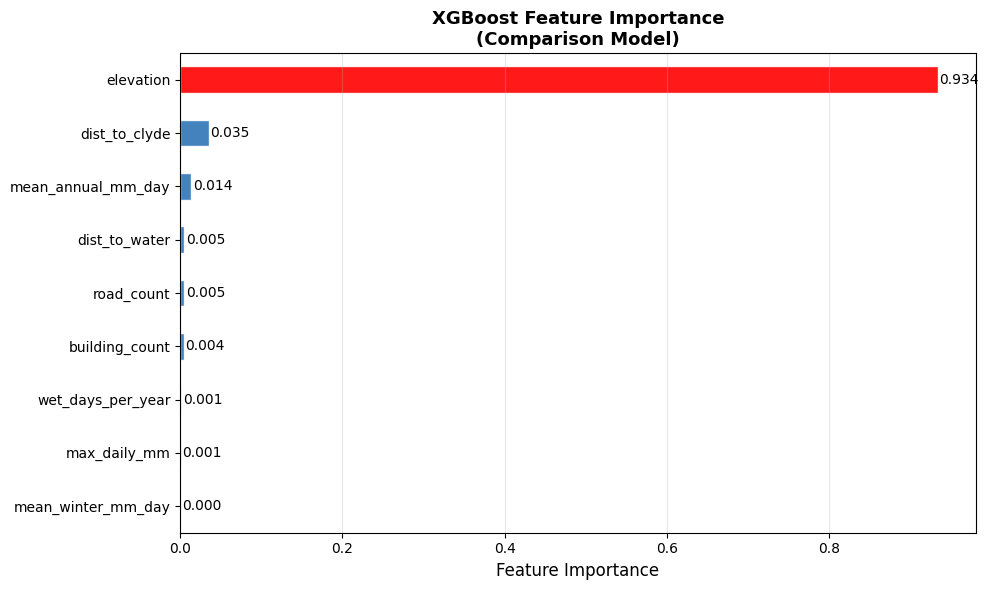

XGBoost feature importance:
  elevation              0.9344
  dist_to_clyde          0.0354
  mean_annual_mm_day     0.0138
  dist_to_water          0.0052
  road_count             0.0049
  building_count         0.0044
  wet_days_per_year      0.0014
  max_daily_mm           0.0006
  mean_winter_mm_day     0.0000


In [26]:
# ── XGBoost feature importance ───────────────────────────────
xgb_importances = pd.Series(xgb_baseline.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#FF0000' if v >= 0.3 else '#ED7D31' if v >= 0.1 else '#2E75B6'
          for v in xgb_importances.values]
xgb_importances.plot.barh(ax=ax, color=colors, edgecolor='white', alpha=0.9)

ax.set_xlabel("Feature Importance", fontsize=12)
ax.set_title("XGBoost Feature Importance\n(Comparison Model)",
             fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

for i, v in enumerate(xgb_importances.values):
    ax.text(v + 0.002, i, f"{v:.3f}", va='center', fontsize=10)

plt.tight_layout()
plt.savefig(f"{MAPS_PATH}/feature_importance_xgboost.png", dpi=150)
plt.show()

print("XGBoost feature importance:")
for feat, imp in xgb_importances.sort_values(ascending=False).items():
    print(f"  {feat:<22} {imp:.4f}")

## XGBoost — SHAP analysis (probability space attempted, raw margin used)
A note on a real library limitation hit here: `shap.TreeExplainer`'s automatic margin→probability
transform only has mappings for binary/regression objectives (e.g. `binary:logistic`). It has no
mapping for `multi:softprob`, XGBoost's multiclass objective, so requesting
`model_output="probability"` on `xgb_baseline` raises `Model does not have a known objective or
output type!`. This is why the Random Forest SHAP above works in probability space directly (its
sklearn tree leaves already store class probabilities) while XGBoost's leaves store raw
log-odds-style margins that would need a softmax applied across all 3 classes jointly — not a
per-output transform TreeExplainer supports for this model type.

So the XGBoost SHAP values below are in **raw margin space**, not probability space like the
Random Forest's. The magnitudes are therefore not directly comparable between the two models —
only the *relative ranking* of features within each model is comparable, which is what the
side-by-side comparison further down uses.

In [27]:
# ── XGBoost SHAP (raw margin space — see note above) ─────────
xgb_explainer = shap.TreeExplainer(xgb_baseline, data=X_train, model_output="raw")
xgb_shap_values = xgb_explainer.shap_values(X_sample)

print("XGBoost SHAP analysis complete!")
print(f"SHAP values shape: {np.array(xgb_shap_values).shape}")

XGBoost SHAP analysis complete!
SHAP values shape: (500, 9, 3)


## Side-by-side comparison — Random Forest vs XGBoost

In [28]:
# ── RF vs XGBoost: accuracy / F1 ─────────────────────────────
rf_acc = accuracy_score(y_test, y_pred)
rf_f1_macro = f1_score(y_test, y_pred, average='macro')
rf_f1_weighted = f1_score(y_test, y_pred, average='weighted')

xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_f1_macro = f1_score(y_test, xgb_pred, average='macro')
xgb_f1_weighted = f1_score(y_test, xgb_pred, average='weighted')

print(f"{'metric':<20}{'Random Forest':>16}{'XGBoost':>12}")
print(f"{'Accuracy':<20}{rf_acc:>16.4f}{xgb_acc:>12.4f}")
print(f"{'F1 macro':<20}{rf_f1_macro:>16.4f}{xgb_f1_macro:>12.4f}")
print(f"{'F1 weighted':<20}{rf_f1_weighted:>16.4f}{xgb_f1_weighted:>12.4f}")

metric                 Random Forest     XGBoost
Accuracy                      0.9962      0.9936
F1 macro                      0.9950      0.9917
F1 weighted                   0.9962      0.9936


In [29]:
# ── RF vs XGBoost: native feature importance ─────────────────
rf_importances = pd.Series(rf_baseline.feature_importances_, index=feature_cols).sort_values(ascending=False)
xgb_importances_ranked = pd.Series(xgb_baseline.feature_importances_, index=feature_cols).sort_values(ascending=False)

print(f"{'feature':<22}{'RF importance':>16}{'XGB importance':>16}")
for feat in feature_cols:
    print(f"{feat:<22}{rf_importances[feat]:>16.4f}{xgb_importances_ranked[feat]:>16.4f}")

feature                  RF importance  XGB importance
elevation                       0.6292          0.9344
dist_to_water                   0.0225          0.0052
dist_to_clyde                   0.1716          0.0354
building_count                  0.0238          0.0044
road_count                      0.0209          0.0049
mean_annual_mm_day              0.0418          0.0138
mean_winter_mm_day              0.0236          0.0000
wet_days_per_year               0.0526          0.0014
max_daily_mm                    0.0142          0.0006


In [30]:
# ── RF vs XGBoost: mean |SHAP| ranking (RF = probability space, XGB = raw margin — see note above) ──
rf_mean_abs_shap = np.abs(shap_values).mean(axis=0).mean(axis=1)
rf_shap_rank = pd.Series(rf_mean_abs_shap, index=feature_cols).sort_values(ascending=False)

xgb_mean_abs_shap = np.abs(xgb_shap_values).mean(axis=0).mean(axis=1)
xgb_shap_rank = pd.Series(xgb_mean_abs_shap, index=feature_cols).sort_values(ascending=False)

print(f"{'feature':<22}{'RF |SHAP| (proba)':>20}{'XGB |SHAP| (raw)':>20}")
for feat in feature_cols:
    print(f"{feat:<22}{rf_shap_rank[feat]:>20.5f}{xgb_shap_rank[feat]:>20.5f}")

print(f"\nRF top 3 (SHAP):  {rf_shap_rank.index[:3].tolist()}")
print(f"XGB top 3 (SHAP): {xgb_shap_rank.index[:3].tolist()}")

feature                  RF |SHAP| (proba)    XGB |SHAP| (raw)
elevation                          0.30961             3.82064
dist_to_water                      0.00764             0.09054
dist_to_clyde                      0.05817             0.11441
building_count                     0.00973             0.13754
road_count                         0.00584             0.15725
mean_annual_mm_day                 0.01940             0.20822
mean_winter_mm_day                 0.01177             0.00000
wet_days_per_year                  0.02336             0.00442
max_daily_mm                       0.00664             0.10734

RF top 3 (SHAP):  ['elevation', 'dist_to_clyde', 'wet_days_per_year']
XGB top 3 (SHAP): ['elevation', 'mean_annual_mm_day', 'road_count']


## Are the dominant features consistent between the two models?

**Elevation** is unambiguously the dominant feature for both models, by every measure (native
importance and SHAP): ~63% RF importance / ~93% XGB importance, and by far the largest mean
|SHAP| in both rankings. That part of the finding is fully consistent.

**`dist_to_clyde`** is the clear #2 feature by native `feature_importances_` in *both* models
(RF ~17%, XGB ~3.5%, both a distant second to elevation but still #2). It also holds #2 in the
Random Forest's probability-space SHAP ranking. However, in XGBoost's SHAP ranking it drops to
around 5th place, behind `mean_annual_mm_day`, `road_count`, and `building_count`. Given that
the XGBoost SHAP values are in raw margin space rather than probability space (see the library
limitation noted above), this is at least partly an artefact of comparing different scales
rather than a genuine disagreement between the models about which features drive risk — but it
should be reported as-is rather than smoothed over: the two models agree strongly on the primary
driver (elevation) and on `dist_to_clyde`'s secondary importance *by native feature importance*,
but are less consistent on `dist_to_clyde`'s SHAP ranking specifically.

## Model selection — Random Forest remains primary
Across accuracy, F1 macro, and F1 weighted, the Random Forest outperforms XGBoost by a small
but consistent margin on this dataset (see comparison table above). Combined with the SHAP
probability-space support that Random Forest has and XGBoost's multiclass objective doesn't,
there is no case for switching the live dashboard model — `rf_baseline` (saved as
`rf_model_40yr.joblib`) remains the model used for `care_dashboard_versionA.py` and
`care_dashboard_versionB.py`. The XGBoost model trained here (`xgb_baseline`) is not saved to
disk; it exists only for this comparison.

## 39-year rainfall retrain — comparison against the original baseline
The primary model above was already trained on the 40yr feature matrix. To show what the
rainfall rework changed, this section reproduces the **original** 3-year-rainfall model fresh
from a frozen snapshot, using an identical pipeline (same split, same hyperparameters, same
probability-space SHAP), and compares it against the already-trained current model — without
retraining the current model a second time.

In [31]:
FEATURE_COLS = feature_cols  # same 9 features used throughout
CLASS_NAMES = ['Low risk', 'Medium risk', 'High risk']

def run_pipeline(csv_path, label):
    d = pd.read_csv(csv_path)
    Xd = d[FEATURE_COLS]
    yd = d['flood_risk']

    Xd_train, Xd_test, yd_train, yd_test = train_test_split(
        Xd, yd, test_size=0.2, random_state=42, stratify=yd
    )

    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(Xd_train, yd_train)

    yd_pred = rf.predict(Xd_test)
    acc = accuracy_score(yd_test, yd_pred)
    f1_macro = f1_score(yd_test, yd_pred, average='macro')
    f1_weighted = f1_score(yd_test, yd_pred, average='weighted')

    importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS) \
        .sort_values(ascending=False)

    Xd_sample = Xd_test.sample(n=500, random_state=42)
    explainer_d = shap.TreeExplainer(rf, data=Xd_train, model_output="probability")
    shap_values_d = explainer_d.shap_values(Xd_sample)

    mean_abs_shap_per_class = np.abs(shap_values_d).mean(axis=0)
    mean_abs_shap = mean_abs_shap_per_class.mean(axis=1)
    shap_ranking = pd.Series(mean_abs_shap, index=FEATURE_COLS).sort_values(ascending=False)

    print(f"\n{'='*60}\n{label}\n{'='*60}")
    print(f"Accuracy:          {acc:.4f}")
    print(f"F1 macro:          {f1_macro:.4f}")
    print(f"F1 weighted:       {f1_weighted:.4f}")
    print(f"\nFeature importance ranking:")
    for feat, imp in importances.items():
        print(f"  {feat:<22} {imp:.4f} ({imp*100:.1f}%)")
    print(f"\nMean |SHAP| (probability space) ranking:")
    for feat, val in shap_ranking.items():
        print(f"  {feat:<22} {val:.5f}")

    return {"model": rf, "acc": acc, "f1_macro": f1_macro, "f1_weighted": f1_weighted,
            "importances": importances, "shap_ranking": shap_ranking}

## Run the pipeline on the original 3-year rainfall snapshot

In [32]:
orig_results = run_pipeline(FEATURE_CSV_3YR, "ORIGINAL (2023-2025 rainfall, 3yr)")


ORIGINAL (2023-2025 rainfall, 3yr)
Accuracy:          0.9955
F1 macro:          0.9942
F1 weighted:       0.9955

Feature importance ranking:
  elevation              0.6164 (61.6%)
  dist_to_clyde          0.1815 (18.2%)
  max_daily_mm           0.0490 (4.9%)
  mean_annual_mm_day     0.0391 (3.9%)
  wet_days_per_year      0.0384 (3.8%)
  building_count         0.0235 (2.4%)
  dist_to_water          0.0233 (2.3%)
  road_count             0.0194 (1.9%)
  mean_winter_mm_day     0.0094 (0.9%)

Mean |SHAP| (probability space) ranking:
  elevation              0.35405
  dist_to_clyde          0.03908
  max_daily_mm           0.00921
  wet_days_per_year      0.00774
  mean_annual_mm_day     0.00748
  building_count         0.00478
  dist_to_water          0.00470
  road_count             0.00363
  mean_winter_mm_day     0.00211


## Package the already-trained current model's results
Reuses `rf_baseline`, `y_test`/`y_pred`, and `shap_values_proba` computed earlier in this
notebook — no retraining, since it's the exact same model on the exact same data.

In [33]:
new_acc = accuracy_score(y_test, y_pred)
new_f1_macro = f1_score(y_test, y_pred, average='macro')
new_f1_weighted = f1_score(y_test, y_pred, average='weighted')
new_importances = pd.Series(rf_baseline.feature_importances_, index=feature_cols) \
    .sort_values(ascending=False)

new_mean_abs_shap_per_class = np.abs(shap_values_proba).mean(axis=0)
new_mean_abs_shap = new_mean_abs_shap_per_class.mean(axis=1)
new_shap_ranking = pd.Series(new_mean_abs_shap, index=feature_cols).sort_values(ascending=False)

new_results = {
    "model": rf_baseline, "acc": new_acc, "f1_macro": new_f1_macro,
    "f1_weighted": new_f1_weighted, "importances": new_importances,
    "shap_ranking": new_shap_ranking,
}

print(f"Current (40yr) model — Accuracy: {new_acc:.4f}, F1 macro: {new_f1_macro:.4f}")

Current (40yr) model — Accuracy: 0.9962, F1 macro: 0.9950


## Side-by-side comparison — accuracy / F1

In [34]:
print(f"{'metric':<20}{'original':>12}{'40yr':>12}")
print(f"{'Accuracy':<20}{orig_results['acc']:>12.4f}{new_results['acc']:>12.4f}")
print(f"{'F1 macro':<20}{orig_results['f1_macro']:>12.4f}{new_results['f1_macro']:>12.4f}")
print(f"{'F1 weighted':<20}{orig_results['f1_weighted']:>12.4f}{new_results['f1_weighted']:>12.4f}")

metric                  original        40yr
Accuracy                  0.9955      0.9962
F1 macro                  0.9942      0.9950
F1 weighted               0.9955      0.9962


## Side-by-side comparison — feature importance & mean |SHAP|

In [35]:
print(f"{'feature':<22}{'orig imp':>10}{'40yr imp':>10}{'orig SHAP':>12}{'40yr SHAP':>12}")
for feat in FEATURE_COLS:
    print(f"{feat:<22}"
          f"{orig_results['importances'][feat]:>10.4f}"
          f"{new_results['importances'][feat]:>10.4f}"
          f"{orig_results['shap_ranking'][feat]:>12.5f}"
          f"{new_results['shap_ranking'][feat]:>12.5f}")

feature                 orig imp  40yr imp   orig SHAP   40yr SHAP
elevation                 0.6164    0.6292     0.35405     0.36229
dist_to_water             0.0233    0.0225     0.00470     0.00479
dist_to_clyde             0.1815    0.1716     0.03908     0.03570
building_count            0.0235    0.0238     0.00478     0.00505
road_count                0.0194    0.0209     0.00363     0.00317
mean_annual_mm_day        0.0391    0.0418     0.00748     0.00753
mean_winter_mm_day        0.0094    0.0236     0.00211     0.00557
wet_days_per_year         0.0384    0.0526     0.00774     0.00725
max_daily_mm              0.0490    0.0142     0.00921     0.00276


## Save the primary (40-year) model to disk

In [36]:
joblib.dump(rf_baseline, MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")

Model saved to /Users/riteshghorpade/Documents/010_Project/002_Dataset/rf_model_40yr.joblib
